# STRAINMETER workflow

Notebook-first workflow for training the two autoencoders and, optionally, running the discriminator on the measured file.

Modes:

- `train only` → train AE1 and AE2
- `train + discriminate` → train AE1 and AE2, then score the measured file
- `solo timeline` → skip training and plot the timeline from existing checkpoints
- `solo ricostruzioni` → train AE1 and AE2, then show final reconstructions


In [1]:
from pathlib import Path
import sys

import importlib
import matplotlib.pyplot as plt
import torch
import pandas as pd
from IPython.display import display, Markdown, Image


try:
    from IPython import get_ipython
    _ip = get_ipython()
    if _ip is not None:
        _ip.run_line_magic('matplotlib', 'inline')
except Exception:
    pass

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


In [2]:
import src.config as config_module
import src.data as data_module
import src.discriminator as discriminator_module
import src.models as models_module
import src.plotting as plotting_module
import src.train as train_module
import src.utils as utils_module

config_module = importlib.reload(config_module)
data_module = importlib.reload(data_module)
discriminator_module = importlib.reload(discriminator_module)
models_module = importlib.reload(models_module)
plotting_module = importlib.reload(plotting_module)
train_module = importlib.reload(train_module)
utils_module = importlib.reload(utils_module)

load_config = config_module.load_config
build_dataloaders = data_module.build_dataloaders
load_waveforms = data_module.load_waveforms
run_discriminator = discriminator_module.run_discriminator
Conv1dAutoencoder = models_module.Conv1dAutoencoder
LiveTrainingPlot = plotting_module.LiveTrainingPlot
plot_reconstructions = plotting_module.plot_reconstructions
plot_discriminator_timeline_interactive = plotting_module.plot_discriminator_timeline_interactive
fit_autoencoder = train_module.fit_autoencoder
ensure_directory = utils_module.ensure_directory
resolve_device = utils_module.resolve_device
set_seed = utils_module.set_seed


In [3]:
display(Markdown('The notebook mode is read from `config.notebook.run_mode`.'))
display(Markdown('Edit `config/config.yaml` if you want to change the default mode.'))


The notebook mode is read from `config.notebook.run_mode`.

Edit `config/config.yaml` if you want to change the default mode.

## 1) Load config and inspect inputs

In [4]:
config_path = PROJECT_ROOT / 'config' / 'config.yaml'
config = load_config(config_path)
set_seed(config.training.seed)
device = resolve_device(config.training.device)
RUN_MODE = config.notebook.run_mode

display(Markdown(f'**Project:** `{config.project_name}`'))
display(Markdown(f'**Device:** `{device}`'))
display(Markdown(f'**Waveform length:** `{config.data.expected_length}`'))
display(Markdown(f'**Training epochs:** `{config.training.epochs}`'))
display(Markdown(f'**Measured file:** `{config.discriminator.measured_path}`'))
display(Markdown(f'**Notebook mode:** `{RUN_MODE}`'))

def resolve_project_path(value: str | Path) -> Path:
    path = Path(value)
    return path if path.is_absolute() else (PROJECT_ROOT / path)

for run in config.autoencoders:
    train_path = resolve_project_path(run.train_path)
    train_waveforms = load_waveforms(train_path, expected_length=config.data.expected_length)
    print(f'{run.name}: {train_path} -> {train_waveforms.shape}')

measured_path = resolve_project_path(config.discriminator.measured_path)
print(f'measured: {measured_path}')


**Project:** `strainmeter_autoencoder`

**Device:** `mps`

**Waveform length:** `128`

**Training epochs:** `100`

**Measured file:** `data/measured/VLPs-2019_low-pass.dat`

**Notebook mode:** `train + discriminate`

AE1: /Users/danielebailo/Hermes/workspace/projects/VLP-STRAINMETER/data/processed/Waveforms_type1_extended_128samples.txt -> (5372, 128)
AE2: /Users/danielebailo/Hermes/workspace/projects/VLP-STRAINMETER/data/processed/Waveforms_type2_extended_128samples.txt -> (3934, 128)
measured: /Users/danielebailo/Hermes/workspace/projects/VLP-STRAINMETER/data/measured/VLPs-2019_low-pass.dat


## 2) Notebook helpers

In [5]:
def resolve_run_output_dir(run) -> Path:
    if run.output_dir:
        return resolve_project_path(run.output_dir)
    return resolve_project_path(config.output_dir) / run.name.lower()

def build_model(run_name: str) -> Conv1dAutoencoder:
    return Conv1dAutoencoder(
        input_channels=config.model.input_channels,
        waveform_length=config.model.waveform_length,
        encoder_channels=list(config.model.encoder_channels),
        kernel_size=config.model.kernel_size,
        stride=config.model.stride,
        padding=config.model.padding,
        latent_dim=config.model.latent_dim,
        activation=config.model.activation,
        batch_norm=config.model.batch_norm,
        dropout=config.model.dropout,
        decoder_type=config.model.decoder_type,
        output_activation=config.model.output_activation,
        name=run_name,
    )

def build_run_loaders(run):
    train_path = resolve_project_path(run.train_path)
    val_path = resolve_project_path(run.val_path) if run.val_path else None
    return build_dataloaders(
        train_path=train_path,
        val_path=val_path,
        expected_length=config.data.expected_length,
        batch_size=config.data.batch_size,
        validation_split=config.data.validation_split,
        shuffle=config.data.shuffle,
        num_workers=config.data.num_workers,
        pin_memory=config.data.pin_memory,
        normalization=config.data.normalization,
        seed=config.training.seed,
    )

def load_trained_model(run):
    output_dir = resolve_run_output_dir(run)
    checkpoint_path = output_dir / 'best_model.pt'
    if not checkpoint_path.exists():
        raise FileNotFoundError(f'Checkpoint not found: {checkpoint_path}')
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model = build_model(run.name).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    return model, output_dir

def summarize_losses(history_csv_path: Path) -> pd.DataFrame:
    history = pd.read_csv(history_csv_path)
    display(history.tail())
    return history

trained_runs = []
run_artifacts = {}
discriminator_artifacts = None


## 3) Train the autoencoders

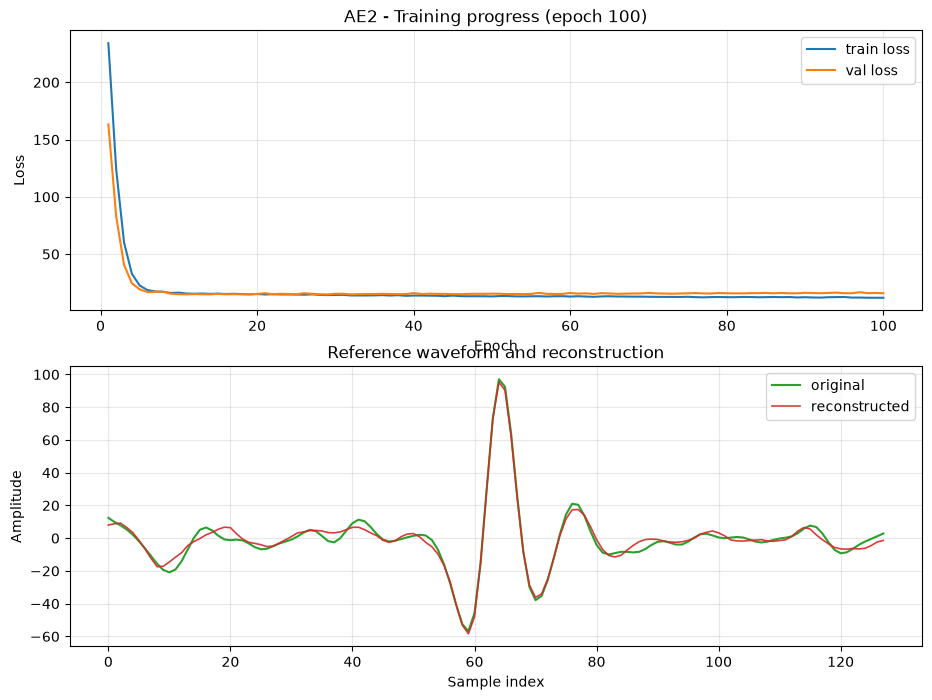

Training completed.
Finished AE2. Best checkpoint: /Users/danielebailo/Hermes/workspace/projects/VLP-STRAINMETER/outputs/ae2_type2/best_model.pt


In [6]:
run_training = RUN_MODE in {'train only', 'train + discriminate', 'solo ricostruzioni'}

if run_training:
    for run in config.autoencoders:
        print(f'\n=== Training {run.name} ===')
        train_loader, val_loader = build_run_loaders(run)
        output_dir = ensure_directory(resolve_run_output_dir(run))
        model = build_model(run.name)
        plotter = LiveTrainingPlot(enabled=config.training.live_plot)
        artifacts = fit_autoencoder(
            model,
            train_loader,
            val_loader,
            config,
            output_dir=output_dir,
            plotter=plotter,
            device=device,
        )
        trained_runs.append((run, artifacts.output_dir))
        run_artifacts[run.name] = artifacts
        print(f'Finished {run.name}. Best checkpoint: {artifacts.best_model_path}')
else:
    print('Training skipped by selected mode.')


## 4) Discrimination timeline

Measured waveforms are longer than the model input (151 -> 128); using a centered crop.

Discriminator summary
Measured file: /Users/danielebailo/Hermes/workspace/projects/VLP-STRAINMETER/data/measured/VLPs-2019_low-pass.dat
AE1 threshold: 36.606884
AE2 threshold: 36.406086
Scores CSV: /Users/danielebailo/Hermes/workspace/projects/VLP-STRAINMETER/outputs/discriminator/discriminator_scores.csv
Timeline plot: /Users/danielebailo/Hermes/workspace/projects/VLP-STRAINMETER/outputs/discriminator/discriminator_timeline.png


Use the dropdown inside the plot to switch between **markers**, **lines**, and **lines + markers**.

Default downsampling step: `1` (change this number in the notebook if you want more or fewer points).

Interactive HTML saved to `/Users/danielebailo/Hermes/workspace/projects/VLP-STRAINMETER/outputs/discriminator/discriminator_timeline_interactive.html`

,waveform_index,type1_score,type2_score,outlier_score
0,0,0.153065,0.199189,0.800811
1,1,0.173051,0.223559,0.776441
2,2,0.141585,0.252047,0.747953
3,3,0.304397,0.369219,0.630781
4,4,0.307749,0.296585,0.692251


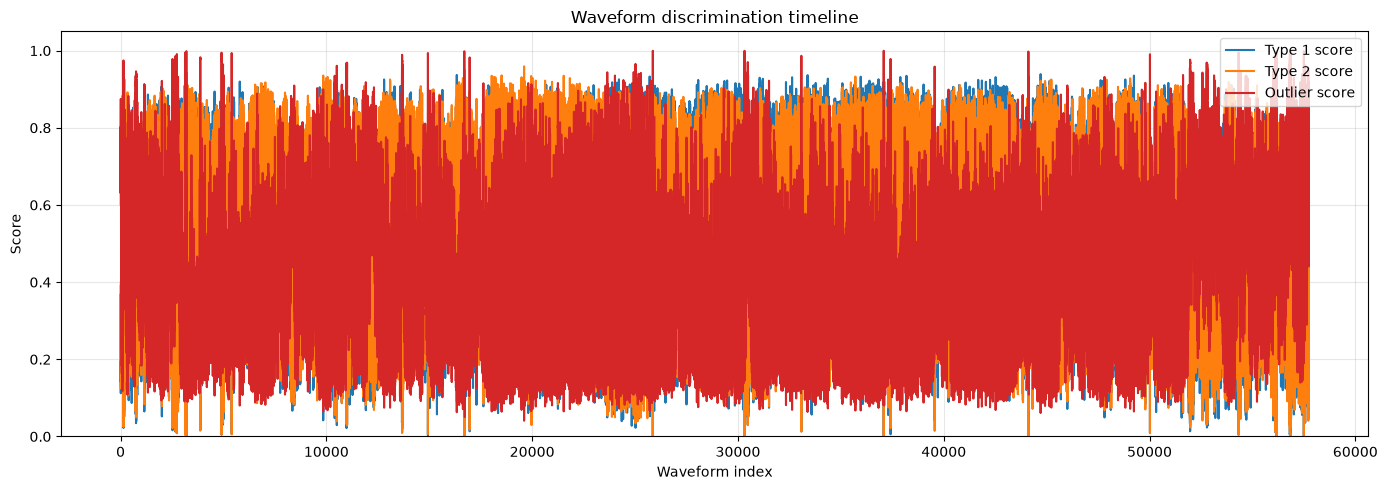

In [7]:
run_discrimination = RUN_MODE in {'train + discriminate', 'solo timeline'}
TIMELINE_DOWNSAMPLE_STEP = 1

if run_discrimination:
    if not trained_runs:
        trained_runs = [(run, resolve_run_output_dir(run)) for run in config.autoencoders]
    missing = [str(output_dir / 'best_model.pt') for _, output_dir in trained_runs if not (output_dir / 'best_model.pt').exists()]
    if missing:
        raise FileNotFoundError('Missing checkpoints:\n' + '\n'.join(missing))

    discriminator_artifacts = run_discriminator(
        config,
        trained_runs,
        project_root=PROJECT_ROOT,
        device=device,
    )
    scores = pd.read_csv(discriminator_artifacts.scores_csv_path)
    display(Markdown('Use the dropdown inside the plot to switch between **markers**, **lines**, and **lines + markers**.'))
    display(Markdown(f'Default downsampling step: `{TIMELINE_DOWNSAMPLE_STEP}` (change this number in the notebook if you want more or fewer points).'))
    interactive_figure = plot_discriminator_timeline_interactive(
        type1_scores=scores['type1_score'].to_numpy(),
        type2_scores=scores['type2_score'].to_numpy(),
        outlier_scores=scores['outlier_score'].to_numpy(),
        title='Interactive discrimination timeline',
        downsample_step=TIMELINE_DOWNSAMPLE_STEP,
        default_style='markers',
    )
    display(interactive_figure)
    interactive_html_path = discriminator_artifacts.output_dir / 'discriminator_timeline_interactive.html'
    interactive_figure.write_html(str(interactive_html_path), include_plotlyjs='cdn')
    display(Markdown(f'Interactive HTML saved to `{interactive_html_path}`'))
    display(scores.head())
else:
    print('Discrimination skipped by selected mode.')


## 5) Final reconstructions

In [8]:
run_reconstructions = RUN_MODE in {'solo ricostruzioni'}

if run_reconstructions:
    for run in config.autoencoders:
        print(f'\n=== Reconstructions for {run.name} ===')
        model, output_dir = load_trained_model(run)
        train_loader, val_loader = build_run_loaders(run)
        preview_loader = val_loader if val_loader is not None else train_loader
        preview_batch = next(iter(preview_loader))
        figure = plot_reconstructions(model, preview_batch, device=device, max_items=4)
        display(figure)
        plt.close(figure)
else:
    print('Reconstruction preview skipped by selected mode.')


Reconstruction preview skipped by selected mode.


## 6) Output summary

In [9]:
print('Done.')
print('Outputs:')
for run in config.autoencoders:
    print(f' - {resolve_run_output_dir(run)}')
print(f' - {resolve_project_path(config.discriminator.output_dir)}')


Done.
Outputs:
 - /Users/danielebailo/Hermes/workspace/projects/VLP-STRAINMETER/outputs/ae1_type1
 - /Users/danielebailo/Hermes/workspace/projects/VLP-STRAINMETER/outputs/ae2_type2
 - /Users/danielebailo/Hermes/workspace/projects/VLP-STRAINMETER/outputs/discriminator
